In [2]:
import os
os.chdir('..')
print(os.getcwd())

/home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
# Raíz del proyecto
PROJECT_ROOT = Path().resolve()
# Ruta a la carpeta de datos procesados
path = PROJECT_ROOT / "data" / "raw"
#df = pd.read_csv(path / 'Dataset_Consolidado.csv')
df_precio = pd.read_csv(path / 'US Coffee C Futures Historical Data.csv')

In [4]:
print(f'Shape: {df_precio.shape}')
print(f'\nColumnas: {df_precio.columns.tolist()}')
print(f'\nPrimeras filas:')
print(df_precio.head())
print(f'\nÚltimas filas:')
print(df_precio.tail())
print(f'\nTipos:')
print(df_precio.dtypes)

Shape: (4894, 7)

Columnas: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']

Primeras filas:
         Date   Price    Open    High     Low    Vol. Change %
0  05/15/2026  266.90  275.00  278.00  265.55  18.42K   -3.19%
1  05/14/2026  275.70  280.65  280.75  274.50  12.53K   -1.80%
2  05/13/2026  280.75  283.05  286.70  279.35  12.56K    0.21%
3  05/12/2026  280.15  282.00  282.85  275.65  15.49K   -0.76%
4  05/11/2026  282.30  275.70  282.70  268.00  19.33K    2.73%

Últimas filas:
            Date   Price    Open    High    Low    Vol. Change %
4889  01/09/2007  118.40  119.40  120.00  118.0  14.69K   -1.42%
4890  01/08/2007  120.10  120.25  120.90  119.2  10.34K   -0.29%
4891  01/05/2007  120.45  123.25  124.00  119.6  19.08K   -3.64%
4892  01/04/2007  125.00  123.80  125.25  122.6  13.39K    1.13%
4893  01/03/2007  123.60  124.30  125.90  122.4  18.09K   -2.06%

Tipos:
Date         object
Price       float64
Open        float64
High        float64
Low         float64
Vo

Precio promedio anual del café (futuros ICE):
      Precio_prom_USc_lb  Precio_prom_USD_ton  Precio_min_USD_ton  Precio_max_USD_ton  n_dias
anio                                                                                         
2007              117.29              2585.85             2234.38             3071.04     249
2008              131.98              2909.57             2239.89             3646.44     253
2009              125.41              2764.78             2282.88             3267.25     253
2010              163.91              3613.62             2815.30             5302.11     260
2011              253.11              5580.12             4650.65             6721.89     258
2012              174.81              3853.95             2943.17             5178.65     253
2013              125.84              2774.36             2237.69             3445.82     253
2014              177.48              3912.71             2438.97             4892.05     254
2015          

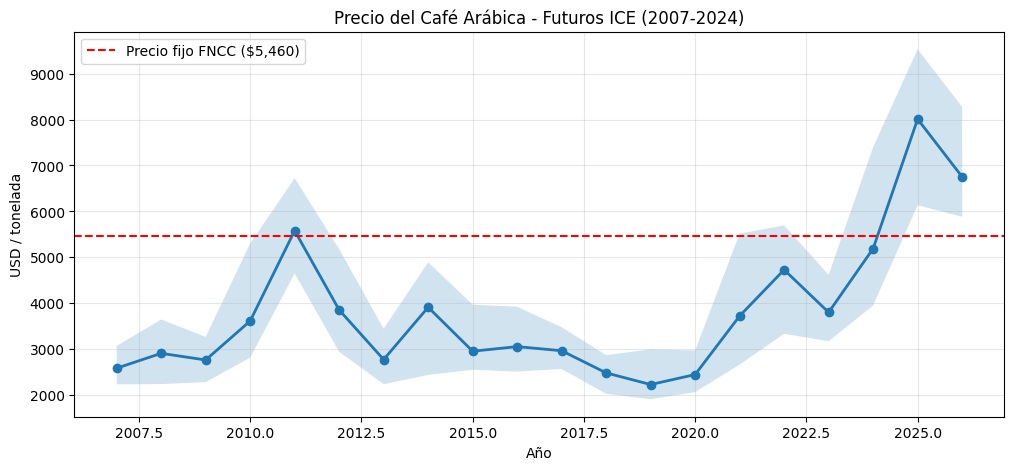

In [5]:
# ── Procesar precios históricos del café ──────────────────────

# Parsear fechas (formato MM/DD/YYYY)
df_precio['Date'] = pd.to_datetime(df_precio['Date'], format='%m/%d/%Y')
df_precio = df_precio.sort_values('Date').reset_index(drop=True)

# Price está en centavos USD por libra (USc/lb) - unidad estándar de ICE
# Conversión: 1 tonelada = 2,204.62 libras
# USD/ton = (USc/lb) / 100 * 2204.62

LIBRAS_POR_TON = 2204.62

df_precio['Precio_USD_ton'] = (df_precio['Price'] / 100) * LIBRAS_POR_TON
df_precio['anio'] = df_precio['Date'].dt.year

# Filtrar solo 2007-2024
df_precio = df_precio[df_precio['anio'].between(2007, 2026)]

# Promedio anual
precio_anual = df_precio.groupby('anio').agg(
    Precio_prom_USc_lb=('Price', 'mean'),
    Precio_prom_USD_ton=('Precio_USD_ton', 'mean'),
    Precio_min_USD_ton=('Precio_USD_ton', 'min'),
    Precio_max_USD_ton=('Precio_USD_ton', 'max'),
    n_dias=('Price', 'count')
).round(2)

print('Precio promedio anual del café (futuros ICE):')
print(precio_anual.to_string())

print(f'\n Resumen')
print(f'  Precio promedio 2007-2024: ${precio_anual["Precio_prom_USD_ton"].mean():.2f} USD/ton')
print(f'  Precio mínimo (año):       ${precio_anual["Precio_prom_USD_ton"].min():.2f} USD/ton ({precio_anual["Precio_prom_USD_ton"].idxmin()})')
print(f'  Precio máximo (año):       ${precio_anual["Precio_prom_USD_ton"].max():.2f} USD/ton ({precio_anual["Precio_prom_USD_ton"].idxmax()})')
print(f'  Precio fijo anterior:      $5,460.00 USD/ton (FNCC)')

# Visualización rápida
plt.figure(figsize=(12, 5))
plt.plot(precio_anual.index, precio_anual['Precio_prom_USD_ton'], 'o-', linewidth=2)
plt.fill_between(precio_anual.index, precio_anual['Precio_min_USD_ton'], 
                 precio_anual['Precio_max_USD_ton'], alpha=0.2)
plt.axhline(5460, color='red', linestyle='--', label='Precio fijo FNCC ($5,460)')
plt.xlabel('Año')
plt.ylabel('USD / tonelada')
plt.title('Precio del Café Arábica - Futuros ICE (2007-2024)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [6]:
# ── Construir tabla de precios de referencia - HISTÓRICO COMPLETO ──

df_precio_sorted = df_precio.sort_values('Date').reset_index(drop=True)

# Promedio móvil 30 días
df_precio_sorted['PM30_USc_lb'] = df_precio_sorted['Price'].rolling(window=30, min_periods=15).mean()
df_precio_sorted['PM30_USD_ton'] = (df_precio_sorted['PM30_USc_lb'] / 100) * LIBRAS_POR_TON

df_precio_sorted['anio'] = df_precio_sorted['Date'].dt.year
df_precio_sorted['mes'] = df_precio_sorted['Date'].dt.month

# Precio de referencia mensual para TODO el histórico
precio_mensual = (
    df_precio_sorted
    .groupby(['anio', 'mes'])
    .agg(
        precio_cierre_USc=('Price', 'last'),
        precio_prom_mes_USc=('Price', 'mean'),
        PM30_cierre_USc=('PM30_USc_lb', 'last'),
        PM30_cierre_USD_ton=('PM30_USD_ton', 'last'),
        n_dias=('Price', 'count')
    )
    .round(2)
    .reset_index()
)

# Eliminar filas con PM30 nulo
precio_mensual = precio_mensual.dropna(subset=['PM30_cierre_USD_ton'])

print(f'Precio mensual completo: {precio_mensual.shape[0]} meses')
print(f'Período: {precio_mensual["anio"].min()}/{precio_mensual["mes"].min():02d} a {precio_mensual["anio"].max()}/{precio_mensual["mes"].max():02d}')
print(f'\nPrimeras filas:')
print(precio_mensual.head(10).to_string(index=False))
print(f'\nÚltimas filas:')
print(precio_mensual.tail(10).to_string(index=False))

# Resumen anual
precio_anual_pm30 = precio_mensual.groupby('anio')['PM30_cierre_USD_ton'].mean().round(2)
print(f'\n PM30 promedio por año (USD/ton)')
print(precio_anual_pm30.to_string())

# Guardar
precio_mensual.to_csv(path / 'precio_cafe_mensual_2007_2026.csv', index=False)


Precio mensual completo: 233 meses
Período: 2007/01 a 2026/12

Primeras filas:
 anio  mes  precio_cierre_USc  precio_prom_mes_USc  PM30_cierre_USc  PM30_cierre_USD_ton  n_dias
 2007    1             117.65               119.25           119.25              2629.01      20
 2007    2             117.70               116.15           116.70              2572.75      19
 2007    3             109.25               111.33           112.73              2485.27      22
 2007    4             103.15               108.32           109.32              2410.20      20
 2007    5             111.90               106.98           106.51              2348.21      22
 2007    6             111.00               114.01           113.32              2498.24      21
 2007    7             114.30               110.93           111.27              2453.12      21
 2007    8             112.65               115.88           115.30              2541.82      23
 2007    9             128.65               122.

In [7]:
# Tabla final de precios de referencia
PATH_MODEL = PROJECT_ROOT / "data" / "model"

ruta_precio_mensual = PATH_MODEL / "precios_cafe_2007-2027.csv"
ruta_precio_anual = PATH_MODEL / "precios_cafe_anual_2007-2027.csv"

# Tabla mensual final
precio_mensual_final = precio_mensual.copy()

# Precio anual para calibración histórica del modelo
precio_anual_final = (
    precio_mensual_final
    .groupby("anio", as_index=False)
    .agg(
        PM30_prom_USD_ton=("PM30_cierre_USD_ton", "mean"),
        PM30_min_USD_ton=("PM30_cierre_USD_ton", "min"),
        PM30_max_USD_ton=("PM30_cierre_USD_ton", "max"),
        n_meses=("mes", "count")
    )
    .round(2)
)

# Guardar ambas tablas
precio_mensual_final.to_csv(ruta_precio_mensual, index=False)
precio_anual_final.to_csv(ruta_precio_anual, index=False)

print("PRECIO ANUAL DE REFERENCIA\n")
print(precio_anual_final.to_string(index=False))

# Tabla de cotización para 2025
print("\n\nTABLA DE COTIZACIÓN 2025")
print("Cuando el caficultor cotiza su seguro, se usa el PM30 del mes de cotización:\n")

precio_2025 = precio_mensual_final[
    precio_mensual_final["anio"] == 2025
][["mes", "PM30_cierre_USD_ton"]].copy()

precio_2025.columns = ["Mes_cotizacion", "Precio_referencia_USD_ton"]

precio_2025["Mes_nombre"] = precio_2025["Mes_cotizacion"].map({
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
    5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
})

print(precio_2025[["Mes_nombre", "Precio_referencia_USD_ton"]].to_string(index=False))

PRECIO ANUAL DE REFERENCIA

 anio  PM30_prom_USD_ton  PM30_min_USD_ton  PM30_max_USD_ton  n_meses
 2007            2581.22           2348.21           2860.09       12
 2008            2921.35           2412.63           3271.36       12
 2009            2745.33           2431.25           3112.52       12
 2010            3572.91           2905.98           4799.22       12
 2011            5581.91           4943.32           6182.23       12
 2012            3880.00           3140.11           4915.61       12
 2013            2786.95           2357.51           3271.95       12
 2014            3879.80           2570.28           4422.91       12
 2015            2978.48           2685.85           3734.99       12
 2016            3046.05           2607.29           3621.20       12
 2017            2973.05           2716.79           3305.13       12
 2018            2494.70           2162.18           2726.16       12
 2019            2216.78           2020.42           2735.38  